In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.shape


(150, 5)

In [ ]:
df['species'].value_counts()


,count
species,
0,50
1,50
2,50


In [ ]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


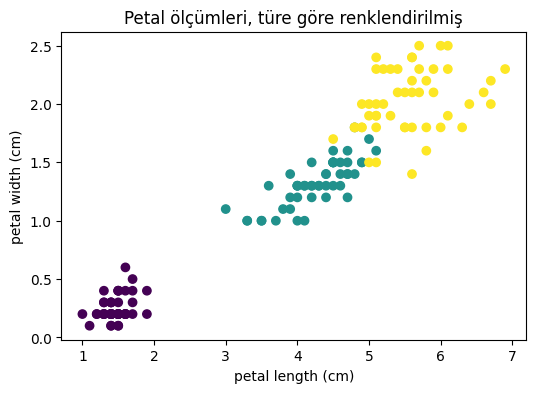

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['species'])
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Petal ölçümleri, türe göre renklendirilmiş')
plt.show()

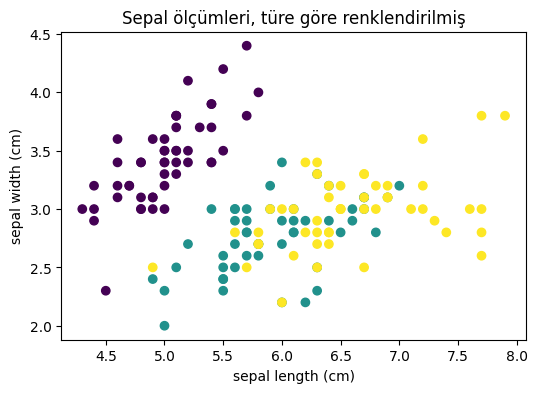

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['species'])
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.title('Sepal ölçümleri, türe göre renklendirilmiş')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = iris.data      # 4 ölçüm
y = iris.target    # tür etiketi

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)


(105, 4) (45, 4)


In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.9777777777777777


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(iris.target_names)

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
['setosa' 'versicolor' 'virginica']


In [ ]:
import numpy as np

probs = model.predict_proba(X_test)
np.set_printoptions(suppress=True, precision=4)

for i in range(5):
    print(f"Gerçek: {y_test[i]}  Tahmin: {y_pred[i]}  Olasılıklar: {probs[i]}")

Gerçek: 1  Tahmin: 1  Olasılıklar: [0.     0.9955 0.0045]
Gerçek: 0  Tahmin: 0  Olasılıklar: [1. 0. 0.]
Gerçek: 2  Tahmin: 2  Olasılıklar: [0. 0. 1.]
Gerçek: 1  Tahmin: 1  Olasılıklar: [0.     0.9749 0.0251]
Gerçek: 1  Tahmin: 1  Olasılıklar: [0.     0.8319 0.1681]


## Gözlemler

- Modellemeden önce scatter plot çizdiğimde petal ölçümlerinin türleri
  sepal ölçümlerinden çok daha net ayırdığını gördüm. Setosa tamamen kopuk
  bir küme oluşturuyor, versicolor ve virginica ise sınırda birbirine değiyor.
- Accuracy %97.8 çıktı (45 test örneğinden 44 doğru).
- Confusion matrix, tek hatanın tam da grafikte beklediğim yerde olduğunu
  gösterdi: bir versicolor, virginica olarak tahmin edilmiş. Setosa'da hiç
  hata yok.
- predict_proba çıktısında modelin her tahminde aynı derecede emin olmadığını
  gördüm. Setosa tahminlerinde olasılık tam 1.0 iken, sınıra yakın bir
  versicolor örneğinde 0.83'e karşı 0.17 çıktı. Accuracy bu farkı gizliyor —
  doğru/yanlış diyor ama ne kadar emin olduğunu söylemiyor.